Step 1: Import Libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report

Step 2: Load Dataset

In [83]:
df = pd.read_csv(r"C:\Users\arjun\OneDrive\Desktop\spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [85]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


 Step 3: Convert Labels to Numbers

In [88]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

Step 4: Convert Text → Numbers (TF-IDF)

In [91]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['message'])
y = df['label']

Step 5: Train-Test Split

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 6: Train Decision Tree Model

In [105]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

Step 7: Prediction

In [110]:
y_pred = model.predict(X_test)

Step 8: Accuracy

In [115]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9524663677130045


In [117]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       965
           1       0.91      0.71      0.80       150

    accuracy                           0.95      1115
   macro avg       0.94      0.85      0.89      1115
weighted avg       0.95      0.95      0.95      1115



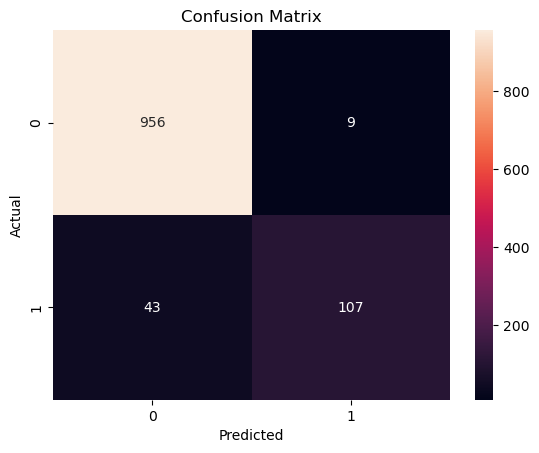

In [63]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

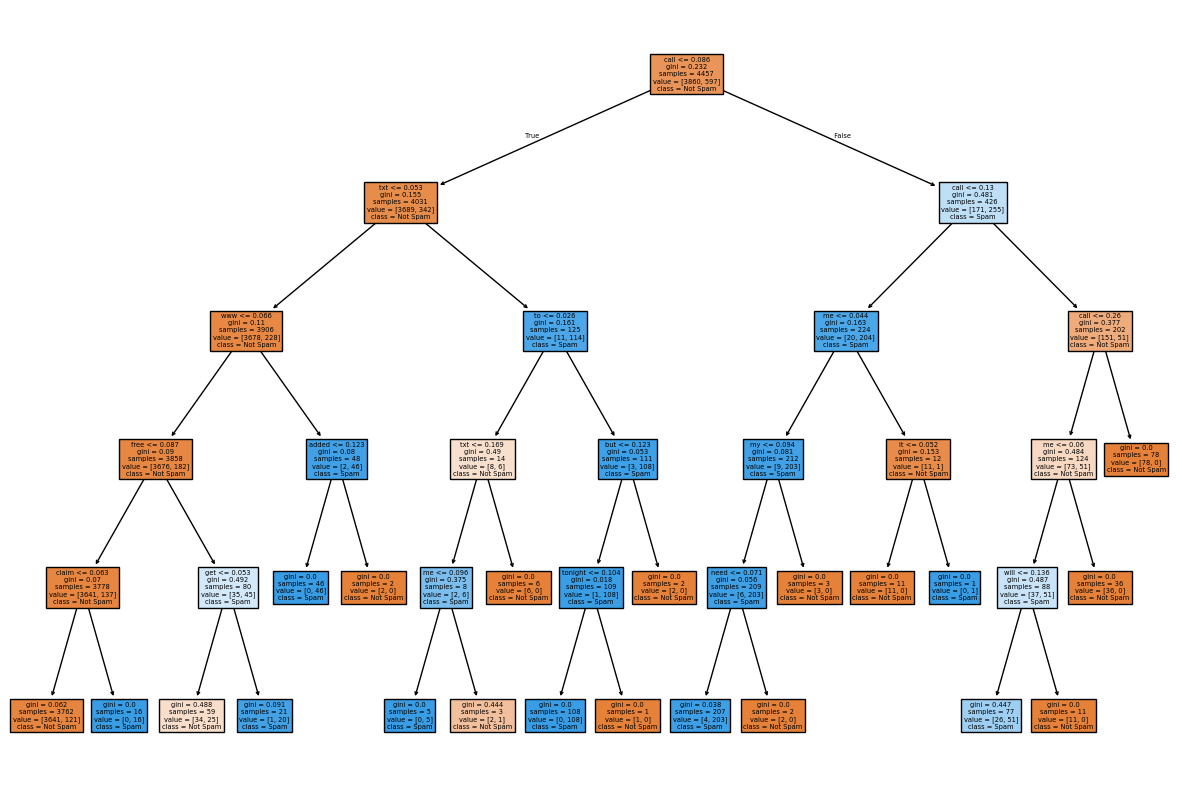

In [65]:
plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=vectorizer.get_feature_names_out(),
    class_names=['Not Spam', 'Spam'],
    filled=True
)
plt.show()